## Actividad 1: Aprendizaje Estadístico-Automático

### Introducción

En este reporte se analizaran los datos y se analizaron características básicas de la
recopilación de información hecha por los investigadores de la Universidad de la Costa en
Colombia. La población de estudio es proveniente de Colombia, Perú y México, con el objetivo
de estudiar factores asociados a distintos niveles de obesidad. Dentro de este reporte se harán
observaciones básicas de la información con la ayuda de Python.

La base de datos original está disponible en el UCI Machine Learning Repository; para esta actividad se
trabajará con una versión simplificada del conjunto de datos.

### Exploración inicial de los datos

Para la exploración inicial de los datos, primero necesitamos entender la población.
Primero importamos los datos a Python. Los datos cuentan con 10 variables distintas, las
cuales son las siguientes:

- Sexo: (cualitativa) muestra si la persona es femenina o masculina.
- Edad: (cuantitativa) muestra la edad de la persona.
- Estatura: (cuantitativa) muestra la estatura de la persona.
- Peso: (cuantitativa) muestra el peso de la persona.
- FamiliarConSobrepeso: (cualitativa) muestra si sí o no tienen un familiar con sobrepeso.
- ComeMuchasCalorias: (cualitativa) muestra si consume calorías en exceso.
- ComeVegetales: (cualitativa) muestra tres niveles de consumo de vegetales.
- Fumador: (cualitativa) muestra si es fumador.
- ConsumoDeAgua: (cualitativa) muestra tres niveles de consumo de agua.
- NivelDeObesidad: (cualitativa) muestra seis niveles de consumo de agua.

In [11]:
import pandas as pd
data = pd.read_csv("A1.1_Obesidad.csv")
print(data.head())

     Sexo  Edad  Estatura  Peso FamiliarConSobrepeso ComeMuchasCalorias  \
0  Female  21.0      1.62  64.0                  yes                 no   
1  Female  21.0      1.52  56.0                  yes                 no   
2    Male  23.0      1.80  77.0                  yes                 no   
3    Male  27.0      1.80  87.0                   no                 no   
4    Male  22.0      1.78  89.8                   no                 no   

   ComeVegetales Fumador  ConsumoDeAgua      NivelDeObesidad  
0            2.0      no            2.0        Normal_Weight  
1            3.0     yes            3.0        Normal_Weight  
2            2.0      no            2.0        Normal_Weight  
3            3.0      no            2.0   Overweight_Level_I  
4            2.0      no            2.0  Overweight_Level_II  


También cabe mencionar el tamaño del estudio. 2111 fue el número de personas totales,
mientras que los primeros dos son el número de mujeres y hombres respectivamente. Estos
números son casi idénticos.

In [12]:
print(sum(data.Sexo == "Female"))
print(sum(data.Sexo == "Male"))
print(sum(data.Sexo == "Female")+sum(data.Sexo == "Male"))

1043
1068
2111


In [13]:
import numpy as np
print(np.mean(data.Edad))
print(sum(data.NivelDeObesidad=="Normal_Weight"))
round(sum(data.NivelDeObesidad=="Normal_Weight")/2111*100,2)


24.312599908574136
287


13.6

El promedio de edad es de 24.3 años, mientras que el modo es de 18. Del total de
personas entrevistadas, nada más 287 cuentan con un peso normal, lo cual equivale al 13.6%
de la población estudiada.

## Reflexión sobre el diseño del estudio

Creo que una variable muy importante de medir es la cantidad de ejercicio que hace
una persona a la semana. La razón de porque esta variable podría ser importante es para
poder ver el impacto que tiene el hacer ejercicio con estar de sobrepeso. Esta variable podría
ser clasificada como cualitativa o cuantitativa, sin embargo creo que para los diseños de la
información de la manera en la que están actualmente, conviene más que la cantidad de
ejercicio se divida en 3 o 4 diferentes secciones, siendo 1 por no hacer ejercicio, 2 hacer una
hora de ejercicio a la semana, y 3 hacer de una a tres horas por ejemplo. El tipo de información
que se podría recopilar con esta nueva variable es saber cuánto impacto tiene el ejercicio en
prevenir la obesidad.

## Definición de una variable de interés para inferencia

La variable más adecuada a ser identificada como variable de salida es la de
NivelDeObesidad. Esto es porque no solo es el enfoque de lo que el estudio está interesado en
describir, pero poniéndola de variable de salida podemos ver como las otras variables impactan
a esta.

In [14]:
iw=sum(data.NivelDeObesidad == "Insufficient_Weight")
nw=sum(data.NivelDeObesidad == "Normal_Weight")
ow1=sum(data.NivelDeObesidad == "Overweight_Level_I")
ow2=sum(data.NivelDeObesidad == "Overweight_Level_II")
ob1=sum(data.NivelDeObesidad == "Obesity_Type_I")
ob2=sum(data.NivelDeObesidad == "Obesity_Type_II")
ob3=sum(data.NivelDeObesidad == "Obesity_Type_III")
print("Insufficient Weight= ", iw," personas ", round(iw/2111*100,2), "%\n",
      "Normal Weight= ", nw," personas ", round(nw/2111*100,2), "%\n",
      "Overweight Level I= ", ow1," personas ", round(ow1/2111*100,2), "%\n",
      "Overwight Level II= ", ow2," personas ", round(ow2/2111*100,2), "%\n",
      "Obesity Type I= ", ob1," personas ", round(ob1/2111*100,2), "%\n",
      "Obesity Type II= ", ob2," personas ", round(ob2/2111*100,2), "%\n",
      "Obesity Type III= ", ob3," personas ", round(ob3/2111*100,2), "%")

Insufficient Weight=  272  personas  12.88 %
 Normal Weight=  287  personas  13.6 %
 Overweight Level I=  290  personas  13.74 %
 Overwight Level II=  290  personas  13.74 %
 Obesity Type I=  351  personas  16.63 %
 Obesity Type II=  297  personas  14.07 %
 Obesity Type III=  324  personas  15.35 %


## Análisis gráfico enfocado en una subpoblación

Escogí a la población masculina y analizar su nivel de obesidad con respecto a los
familiares con sobrepeso. Para hacer esto, hice una gráfica de barras que muestra cada
categoría de los niveles de obesidad, con cuántos de ellos dicen familiares tienen o no tienen
familiares con sobrepeso. En los resultados se puede apreciar cómo es que las personas con
menos peso son las que tienen más familiares que no padecen de sobrepeso, mientras que
suben las categorías del sobrepeso, este nivel va decrementando. Para la gente con obesidad
tipo 2 y 3, básicamente todos ellos cuentan con un familiar con sobrepeso.

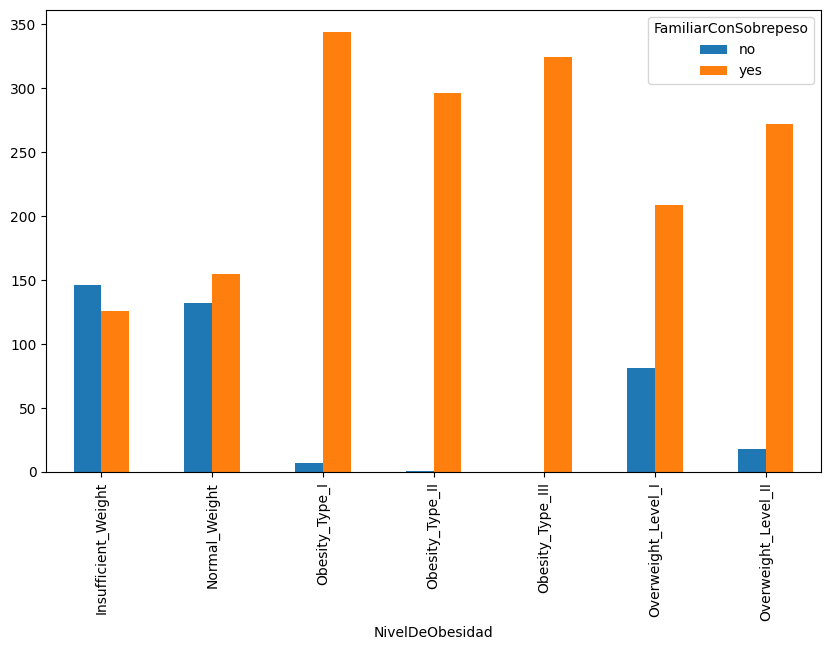

In [15]:
%matplotlib inline
import matplotlib.pyplot as plt

counts = data.groupby(['NivelDeObesidad', 'FamiliarConSobrepeso']).size().unstack(fill_value=0)
ax = counts.plot(kind='bar', figsize=(10,6))